# Environmental Monitoring & Pollution Control — AI/ML Project

**Generated:** 2025-08-28 15:20:52 UTC

This notebook loads the provided dataset and walks through a complete project:

- Data Exploration & Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Machine Learning Models (regression/classification)
- Model Evaluation & Visualization
- Predictive alerts and control-action suggestions

Replace the sample file path if needed. The notebook attempts to detect common columns like 'CO', `NH`, `NO2`, `OZONE`, `PM10`, `PM2.5`, 'SO2'.

### How to use
1. Run cells top-to-bottom. The notebook attempts to install missing Python packages when necessary.
2. If mapping or advanced plotting packages are not available, install them as prompted.

---


## 1) Setup: imports and configuration

This cell imports libraries and performs lightweight package installation if missing.

In [1]:
# Setup: imports and light installs (will try to install packages if missing)
import sys
import os
from pathlib import Path
DATA_PATH = Path('Dataset_Cities.csv')

# Attempt to import required packages and install if missing (only common packages)
required = [
    "pandas", "numpy", "matplotlib", "seaborn", "sklearn", "joblib", "scipy"
]
# Optional but useful
optional = ["folium", "plotly", "xgboost"]

def install(pkg):
    print(f"Installing {pkg} ...")
    os.system(f"{sys.executable} -m pip install --quiet {pkg}")

for pkg in required:
    try:
        __import__(pkg)
    except Exception:
        install(pkg)

for pkg in optional:
    try:
        __import__(pkg)
    except Exception:
        print(f"Optional package {pkg} not available — some features may be skipped. To enable, run pip install {pkg}")

# Now import
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix, classification_report
import joblib
plt.rcParams['figure.figsize'] = (10,6)
sns.set(style='whitegrid')
print('Imports complete.')
print('Data path:', DATA_PATH)


Optional package folium not available — some features may be skipped. To enable, run pip install folium
Optional package plotly not available — some features may be skipped. To enable, run pip install plotly
Imports complete.
Data path: Dataset_Cities.csv


## 2) Load & Inspect Data

Load the CSV provided by the user and show a top preview, basic info, and missing value summary.

In [2]:
# Load dataset
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Data file not found at {DATA_PATH}. Please upload the CSV to that path.")
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
display(df.head(10))
print('\nColumns and dtypes:')
print(df.dtypes)
print('\nMissing values per column:')
print(df.isna().sum().sort_values(ascending=False).head(30))

Shape: (3164, 11)


,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Bihar,Aurangabad,"Gurdeo Nagar, Aurangabad - BSPCB",28-08-2025 19:00:00,24.757460,84.366208,PM10,25.0,166.0,73.0
1,India,Bihar,Begusarai,"Lohiyanagar, Begusarai - BSPCB",28-08-2025 19:00:00,25.427420,86.138861,NH3,3.0,4.0,4.0
2,India,Bihar,Bettiah,"Kamalnath Nagar, Bettiah - BSPCB",28-08-2025 19:00:00,26.803650,84.519540,PM10,5.0,59.0,32.0
3,India,Bihar,Bettiah,"Kamalnath Nagar, Bettiah - BSPCB",28-08-2025 19:00:00,26.803650,84.519540,NO2,5.0,12.0,8.0
4,India,Bihar,Bettiah,"Kamalnath Nagar, Bettiah - BSPCB",28-08-2025 19:00:00,26.803650,84.519540,CO,39.0,75.0,59.0
5,India,Bihar,Bettiah,"Kamalnath Nagar, Bettiah - BSPCB",28-08-2025 19:00:00,26.803650,84.519540,OZONE,23.0,25.0,24.0
6,India,Bihar,Bhagalpur,"DM Office_Kachari Chowk, Bhagalpur - BSPCB",28-08-2025 19:00:00,25.251013,86.989001,PM2.5,7.0,53.0,30.0
7,India,Bihar,Bhagalpur,"DM Office_Kachari Chowk, Bhagalpur - BSPCB",28-08-2025 19:00:00,25.251013,86.989001,NH3,2.0,4.0,3.0
8,India,Assam,Silchar,"Tarapur, Silchar - PCBA",28-08-2025 19:00:00,24.828270,92.795250,NH3,1.0,1.0,1.0
9,India,Assam,Sivasagar,"Girls College, Sivasagar - PCBA",28-08-2025 19:00:00,26.987634,94.636574,PM2.5,25.0,41.0,29.0



Columns and dtypes:
country           object
state             object
city              object
station           object
last_update       object
latitude         float64
longitude        float64
pollutant_id      object
pollutant_min    float64
pollutant_max    float64
pollutant_avg    float64
dtype: object

Missing values per column:
pollutant_min    269
pollutant_avg    269
pollutant_max    269
city               0
state              0
country            0
station            0
longitude          0
latitude           0
last_update        0
pollutant_id       0
dtype: int64


## 3) Data Cleaning & Handling Missing Values

Strategies applied:
- Parse timestamps
- Handle missing numeric values (median/imputation)
- Handle categorical/null location values
- Drop duplicates
- Basic type conversions

In [3]:
# Make a copy
data = df.copy()

# Try to find a timestamp column
time_cols = [c for c in data.columns if 'time' in c.lower() or 'date' in c.lower() or 'timestamp' in c.lower()]
print("Candidate time columns:", time_cols)
if len(time_cols) > 0:
    tcol = time_cols[0]
    print('Using timestamp column:', tcol)
    try:
        # Explicit parsing: allow day-first just in case (avoids warnings)
        data[tcol] = pd.to_datetime(data[tcol], dayfirst=True, errors='coerce')
    except Exception as e:
        print('Failed to parse timestamp:', e)
        tcol = None
else:
    tcol = None
    print('No obvious timestamp column found. You can create one if you have date components.')

# Drop exact duplicates
before = data.shape[0]
data = data.drop_duplicates().reset_index(drop=True)
after = data.shape[0]
print(f"Dropped {before-after} exact duplicates. New shape: {data.shape}")

# Numeric and categorical columns
num_cols = data.select_dtypes(include=['number']).columns.tolist()
cat_cols = data.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('Numeric cols sample:', num_cols[:10])
print('Categorical cols sample:', cat_cols[:10])

# Fill numeric missing values with median per column
for c in num_cols:
    med = data[c].median()
    if pd.notna(med):
        data[c] = data[c].fillna(med)

# For timestamp, forward/backward fill small gaps if present
if tcol:
    data = data.sort_values(by=tcol).reset_index(drop=True)
    data[tcol] = data[tcol].ffill().bfill()   # ✅ modern replacement

# For categorical, fill with 'unknown'
for c in cat_cols:
    data[c] = data[c].fillna('unknown').astype(str)

print('Missing values after basic imputation:')
print(data.isna().sum().sum(), 'total missing values')

Candidate time columns: ['last_update']
Using timestamp column: last_update
Dropped 0 exact duplicates. New shape: (3164, 11)
Numeric cols sample: ['latitude', 'longitude', 'pollutant_min', 'pollutant_max', 'pollutant_avg']
Categorical cols sample: ['country', 'state', 'city', 'station', 'pollutant_id']
Missing values after basic imputation:
0 total missing values


## 4) Exploratory Data Analysis (EDA)

We will:
- Look at pollution distributions (PM2.5, PM10, NO2, etc.)
- Compute correlations
- Time trends
- Geographic mapping (if latitude/longitude exist)
- Heatmaps and pairplots

City-like columns detected: ['city']


,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2
city,,,,,,,
Rupnagar,95.0,NaN,5.0,NaN,60.0,54.0,9.0
Coimbatore,92.0,1.5,8.0,4.0,29.5,31.5,13.0
Katihar,88.0,1.0,14.0,13.0,33.0,44.0,22.0
Eloor,87.0,NaN,8.0,12.0,59.0,98.0,1.0
Rajgir,86.0,7.0,9.0,34.0,47.0,33.0,21.0
...,...,...,...,...,...,...,...
Panchgaon,NaN,5.0,13.0,40.0,101.0,157.0,6.0
Pudukottai,NaN,2.0,13.0,NaN,24.0,18.0,12.0
Ratlam,NaN,NaN,35.0,NaN,28.0,17.0,31.0


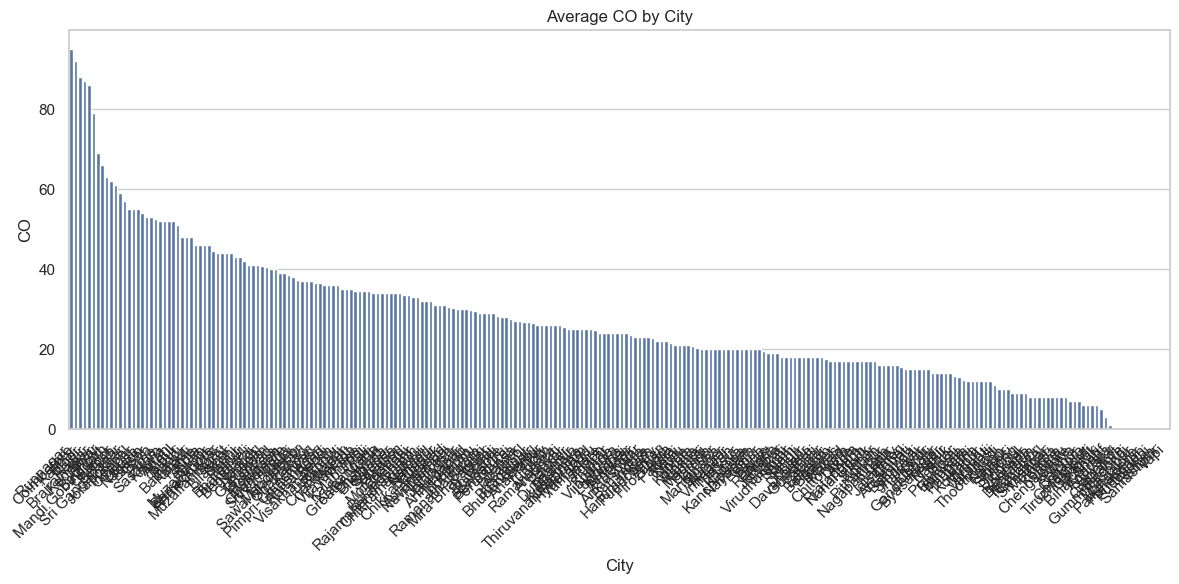

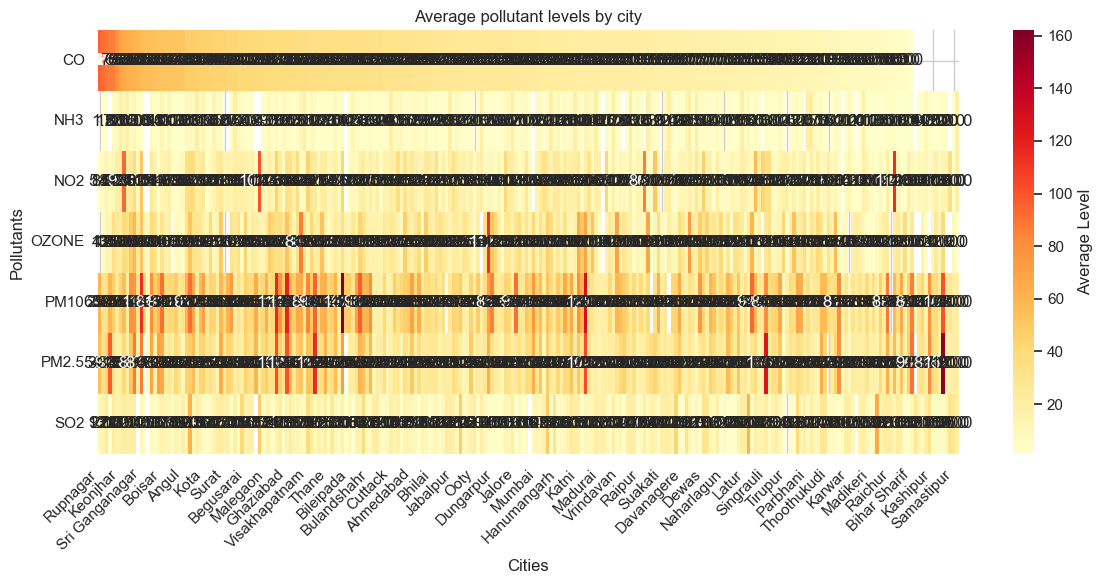

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Detect city/location columns
city_cols = [c for c in data.columns if 'city' in c.lower() or 'location' in c.lower()]
print('City-like columns detected:', city_cols)

if city_cols:
    cityc = city_cols[0]

    # Pivot pollutants into wide format
    pivoted = data.pivot_table(
        index=cityc,
        columns="pollutant_id",
        values="pollutant_avg",
        aggfunc="mean"
    )

    # Clean column names
    pivoted.columns.name = None  
    city_summary = pivoted.sort_values(by=pivoted.columns[0], ascending=False)

    # Show summary table
    display(city_summary)

    # --- Barplot for first pollutant ---
    first_pollutant = city_summary.columns[0]
    plt.figure(figsize=(12,6))

    sns.barplot(
        x=city_summary.index,
        y=city_summary[first_pollutant].values,
        errorbar=None   # ✅ replaced ci=None
    )

    plt.xticks(rotation=45, ha="right")
    plt.title(f"Average {first_pollutant} by City")
    plt.ylabel(first_pollutant)
    plt.xlabel("City")
    plt.tight_layout()
    plt.show()

    # --- Heatmap for all pollutants ---
    plt.figure(figsize=(12,6))
    sns.heatmap(
        city_summary.T,
        cmap="YlOrRd",
        annot=True,
        fmt=".1f",
        cbar_kws={'label': 'Average Level'}
    )

    plt.title("Average pollutant levels by city")
    plt.ylabel("Pollutants")
    plt.xlabel("Cities")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

else:
    print("No city/location column found — can't compare across cities.")


## 5) Feature Engineering

Create useful features:
- Pollution index (normalized combination)
- Temporal features (hour, dayofweek, month)
- Lag features and rolling means
- Weather interaction features

In [12]:
from sklearn.preprocessing import MinMaxScaler

feat = data.copy()

# Pivot pollutants first (so each pollutant is a column)
feat = feat.pivot_table(
    index=["state", "city", "station", "last_update", "latitude", "longitude"],
    columns="pollutant_id",
    values="pollutant_avg",
    aggfunc="mean"
).reset_index()

# Detect numeric pollutant columns
num_cols = feat.select_dtypes(include="number").columns.tolist()
pollutants = [c for c in num_cols if c not in ["latitude", "longitude"]]

print("Detected pollutant columns:", pollutants)

# --- Pollution index ---
if pollutants:
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(feat[pollutants].fillna(0))
    feat['pollution_index'] = np.nanmean(scaled, axis=1)
    print('pollution_index created from:', pollutants)
else:
    print('No pollutant columns to create pollution_index.')

# --- Temporal features ---
tcol = "last_update" if "last_update" in feat.columns else None

if tcol:
    # Convert to datetime
    feat[tcol] = pd.to_datetime(feat[tcol], errors="coerce")

    feat['hour'] = feat[tcol].dt.hour
    feat['dayofweek'] = feat[tcol].dt.dayofweek
    feat['month'] = feat[tcol].dt.month
else:
    print('No timestamp; temporal features skipped.')

# --- Rolling features (24h, 7d) ---
if tcol:
    feat = feat.sort_values(tcol)
    for p in pollutants:
        feat[f'{p}_roll_24h'] = feat[p].rolling(window=24, min_periods=1).mean()
        feat[f'{p}_roll_7d'] = feat[p].rolling(window=24*7, min_periods=1).mean()

print('Feature engineering complete. Sample:')
display(feat.head())

Detected pollutant columns: ['CO', 'NH3', 'NO2', 'OZONE', 'PM10', 'PM2.5', 'SO2']
pollution_index created from: ['CO', 'NH3', 'NO2', 'OZONE', 'PM10', 'PM2.5', 'SO2']
Feature engineering complete. Sample:


pollutant_id,state,city,station,last_update,latitude,longitude,CO,NH3,NO2,OZONE,...,NO2_roll_24h,NO2_roll_7d,OZONE_roll_24h,OZONE_roll_7d,PM10_roll_24h,PM10_roll_7d,PM2.5_roll_24h,PM2.5_roll_7d,SO2_roll_24h,SO2_roll_7d
0,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",2025-08-28 19:00:00,16.515083,80.518167,15.0,4.0,21.0,17.0,...,21.000000,21.000000,17.00,17.00,28.000000,28.000000,13.0,13.0,14.0,14.0
324,Rajasthan,Jaipur,"Shastri Nagar, Jaipur - RSPCB",2025-08-28 19:00:00,26.950293,75.730943,86.0,6.0,28.0,25.0,...,24.500000,24.500000,21.00,21.00,49.000000,49.000000,34.0,34.0,16.5,16.5
323,Rajasthan,Jaipur,"Sector-2 Murlipura, Jaipur - RSPCB",2025-08-28 19:00:00,26.960669,75.771817,25.0,2.0,25.0,9.0,...,24.666667,24.666667,17.00,17.00,48.333333,48.333333,34.0,34.0,12.0,12.0
322,Rajasthan,Jaipur,"RIICO Sitapura, Jaipur - RSPCB",2025-08-28 19:00:00,26.786682,75.827928,29.0,3.0,21.0,42.0,...,23.750000,23.750000,23.25,23.25,50.000000,50.000000,34.5,34.5,10.0,10.0
321,Rajasthan,Jaipur,"Police Commissionerate, Jaipur - RSPCB",2025-08-28 19:00:00,26.916409,75.799490,69.0,9.0,93.0,19.0,...,37.600000,37.600000,22.40,22.40,54.000000,54.000000,39.8,39.8,10.6,10.6


## 6) Machine Learning: Predict pollution levels

We will:
- Define a target (pollution_index or a specific pollutant)
- Train/test split
- Train baseline linear regression and Random Forest
- Optionally train XGBoost if available
- Save models and show feature importance

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import pandas as pd
import numpy as np

# Choose target
target = 'pollution_index' if 'pollution_index' in feat.columns else (pollutants[0] if pollutants else num_cols[0])
print('Using target:', target)

# --- Prepare X, y ---
exclude = [target, "country", "state", "city", "station", "last_update"]  # drop IDs
X = feat.drop(columns=[c for c in exclude if c in feat.columns], errors="ignore")

# Convert categorical → dummies
X = pd.get_dummies(X, drop_first=True)

# Fill NaN
X = X.fillna(0)
y = feat[target].fillna(feat[target].median())

# Align shapes
X = X.loc[y.index]

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

# --- Classification or Regression? ---
is_classification = False
if y.nunique() <= 5 and y.dtype.kind in 'biu':  # heuristic
    is_classification = True
    print('Treating as classification task.')
else:
    print('Treating as regression task.')

models = {}

if not is_classification:
    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    models['LinearRegression'] = lr

    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    models['RandomForest'] = rf

    # XGBoost if available
    try:
        import xgboost as xgb
        xg = xgb.XGBRegressor(n_estimators=200, random_state=42, n_jobs=4, verbosity=0)
        xg.fit(X_train, y_train)
        models['XGBoost'] = xg
    except Exception as e:
        print('XGBoost not available or failed to train:', e)

else:
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    models['RandomForestClassifier'] = clf

print('Trained models:', list(models.keys()))

Using target: pollution_index
Train shape: (380, 26) Test shape: (96, 26)
Treating as regression task.
Trained models: ['LinearRegression', 'RandomForest', 'XGBoost']


## 7) Evaluation & Visualization

Compute RMSE, MAE, R2 for regression or Accuracy, Confusion Matrix for classification. Plot predictions vs true values and feature importances.

Model: LinearRegression -> RMSE: 0.0000, MAE: 0.0000, R2: 1.0000


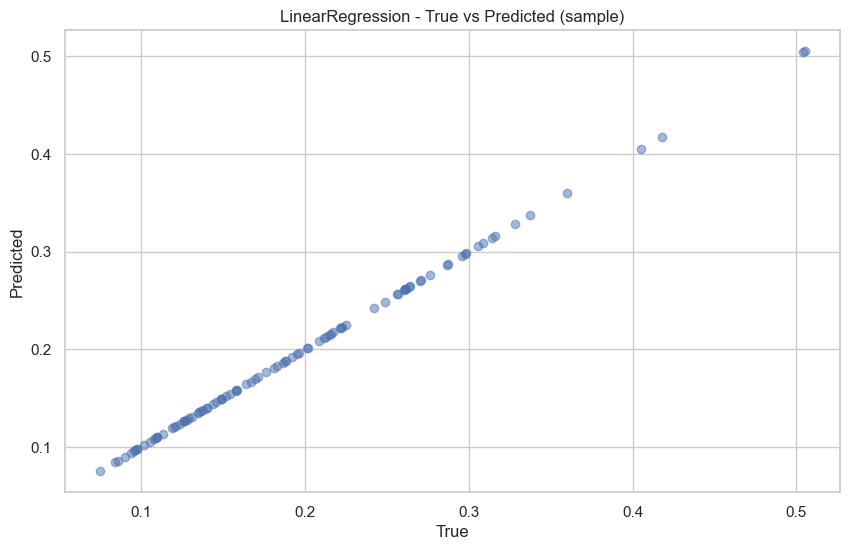

Model: RandomForest -> RMSE: 0.0317, MAE: 0.0218, R2: 0.8724


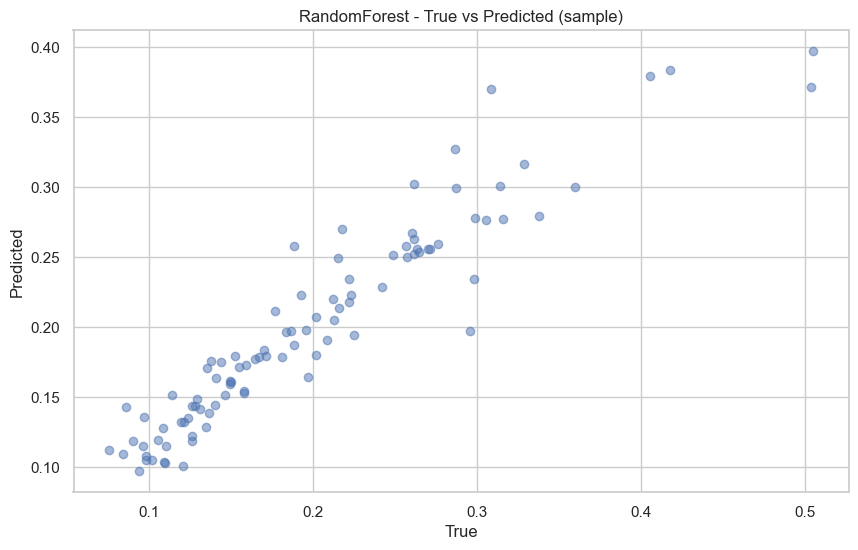

pollutant_id
NH3               0.335561
PM10              0.167458
PM2.5             0.166673
NO2               0.106340
CO                0.091847
latitude          0.026062
SO2               0.020265
OZONE             0.019097
NH3_roll_24h      0.006095
longitude         0.005998
NO2_roll_24h      0.005329
NH3_roll_7d       0.005294
SO2_roll_24h      0.005195
PM2.5_roll_24h    0.005093
OZONE_roll_24h    0.004895
CO_roll_7d        0.004733
CO_roll_24h       0.004306
OZONE_roll_7d     0.004121
PM10_roll_24h     0.003711
PM10_roll_7d      0.003621
dtype: float64

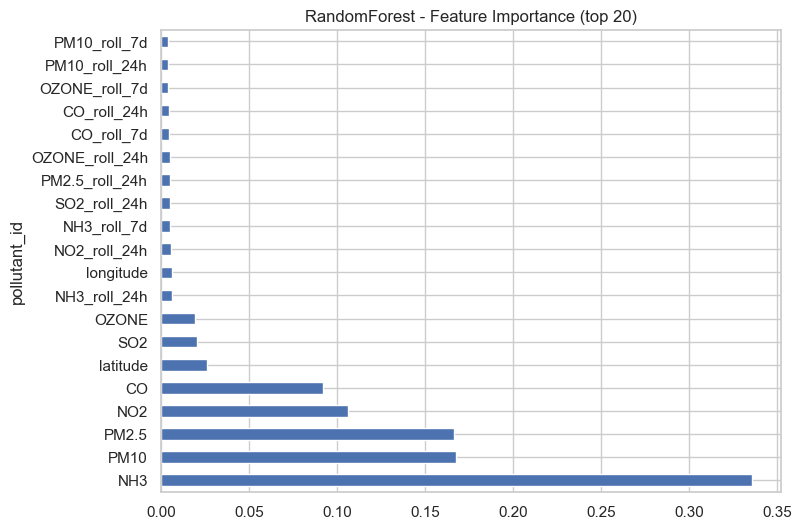

Model: XGBoost -> RMSE: 0.0310, MAE: 0.0226, R2: 0.8779


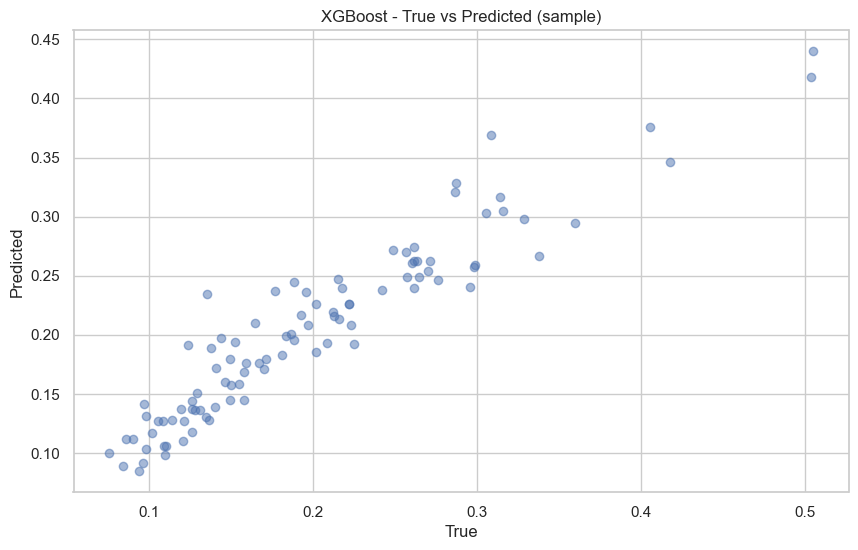

pollutant_id
NH3               0.374967
PM2.5             0.200830
PM10              0.187247
CO                0.054432
NO2               0.054352
SO2               0.024603
OZONE             0.023770
NH3_roll_7d       0.019047
OZONE_roll_7d     0.014505
latitude          0.006725
NH3_roll_24h      0.005568
CO_roll_7d        0.005130
longitude         0.005102
PM10_roll_7d      0.005102
PM2.5_roll_24h    0.003804
NO2_roll_24h      0.003023
SO2_roll_24h      0.002821
CO_roll_24h       0.002406
PM2.5_roll_7d     0.002180
NO2_roll_7d       0.001548
dtype: float32

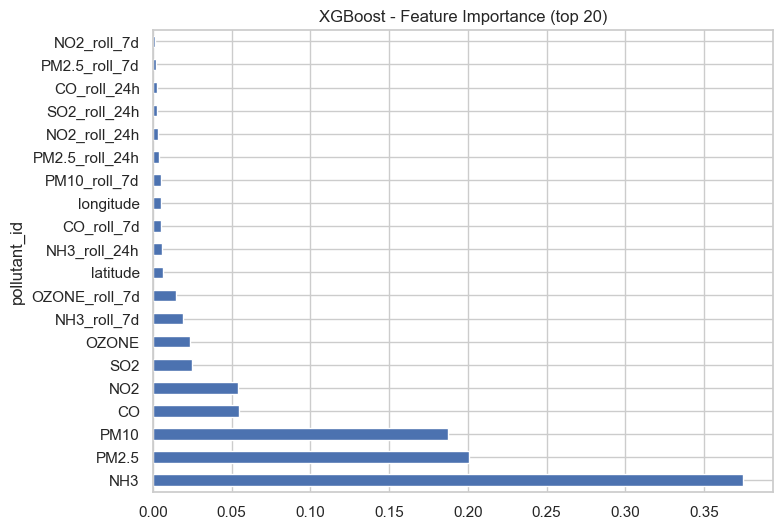

Summary results:


,RMSE,MAE,R2
LinearRegression,1.734666e-16,1.423919e-16,1.000000
RandomForest,3.172845e-02,2.184217e-02,0.872444
XGBoost,3.103714e-02,2.263699e-02,0.877942


In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix, classification_report

results = {}
for name, m in models.items():
    if not is_classification:
        # Predictions
        y_pred = m.predict(X_test.fillna(0))

        # Metrics (compatible with old sklearn)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
        print(f"Model: {name} -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

        # Scatter plot: True vs Predicted (sample up to 500 points)
        plt.figure()
        sample_idx = y_test.sample(min(500, len(y_test))).index
        plt.scatter(y_test.loc[sample_idx], pd.Series(y_pred, index=y_test.index).loc[sample_idx], alpha=0.5)
        plt.xlabel('True'); plt.ylabel('Predicted')
        plt.title(f'{name} - True vs Predicted (sample)')
        plt.show()

        # Feature importance for tree-based models
        if hasattr(m, 'feature_importances_'):
            imp = pd.Series(m.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)
            display(imp)
            plt.figure(figsize=(8,6))
            imp.plot(kind='barh')
            plt.title(f'{name} - Feature Importance (top 20)')
            plt.show()

    else:
        # Classification path
        y_pred = m.predict(X_test.fillna(0))

        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)

        results[name] = {'Accuracy': acc, 'ConfusionMatrix': cm}
        print(f"Model: {name} -> Accuracy: {acc:.4f}")
        print('Classification report:')
        print(classification_report(y_test, y_pred))

        sns.heatmap(cm, annot=True, fmt='d')
        plt.title(f'{name} - Confusion Matrix')
        plt.show()

# Final summary table
print('Summary results:')
display(pd.DataFrame(results).T)


## 8) AI for Pollution Control Insight: Alerts & Control Actions

Create simple rules for predictive alerts and recommended control actions based on model predictions.

In [15]:
# Predict on recent samples and create alerts
latest = X.tail(100)
for name, m in models.items():
    pred = m.predict(latest.fillna(0))
    # elevate alert where prediction above 90th percentile of training target distribution
    threshold = np.percentile(y_train, 90)
    alerts = pred > threshold if not is_classification else (pred != 0)
    alert_count = alerts.sum()
    print(f'Model {name}: {alert_count}/{len(latest)} predicted above threshold ({threshold:.2f})')
    # Show sample alerts
    alerted_idx = np.where(alerts)[0][:10]
    if len(alerted_idx)>0:
        print('Sample alert indices in the recent window:', alerted_idx)
        # Show associated features for first few alerts
        display(latest.iloc[alerted_idx].head(5))

# Suggested control actions (textual)
suggestions = [
    "Issue public health advisory when pollution_index > 90th percentile.",
    "Reduce traffic flow in affected zones (congestion pricing / temporary restrictions).",
    "Temporarily reduce industrial emissions via permit controls during predicted high-pollution events.",
    "Activate green-surface measures: increase water spraying on roads where appropriate, restrict open burning.",
    "Enhance monitoring frequency and deploy mobile sensors to hotspots flagged by the model.",
    "Trigger indoor-air quality messages to vulnerable populations and offer masks/clean-air shelter guidance."
]
print('\\nRecommended control actions:')
for s in suggestions:
    print('-', s)

Model LinearRegression: 1/100 predicted above threshold (0.31)
Sample alert indices in the recent window: [62]


pollutant_id,latitude,longitude,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2,hour,...,NO2_roll_24h,NO2_roll_7d,OZONE_roll_24h,OZONE_roll_7d,PM10_roll_24h,PM10_roll_7d,PM2.5_roll_24h,PM2.5_roll_7d,SO2_roll_24h,SO2_roll_7d
125,30.943887,76.801991,48.0,8.0,38.0,52.0,91.0,47.0,62.0,19,...,22.363636,20.783951,23.347826,23.52795,37.913043,51.518293,25.952381,42.159509,17.166667,14.832298


Model RandomForest: 1/100 predicted above threshold (0.31)
Sample alert indices in the recent window: [62]


pollutant_id,latitude,longitude,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2,hour,...,NO2_roll_24h,NO2_roll_7d,OZONE_roll_24h,OZONE_roll_7d,PM10_roll_24h,PM10_roll_7d,PM2.5_roll_24h,PM2.5_roll_7d,SO2_roll_24h,SO2_roll_7d
125,30.943887,76.801991,48.0,8.0,38.0,52.0,91.0,47.0,62.0,19,...,22.363636,20.783951,23.347826,23.52795,37.913043,51.518293,25.952381,42.159509,17.166667,14.832298


Model XGBoost: 1/100 predicted above threshold (0.31)
Sample alert indices in the recent window: [62]


pollutant_id,latitude,longitude,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2,hour,...,NO2_roll_24h,NO2_roll_7d,OZONE_roll_24h,OZONE_roll_7d,PM10_roll_24h,PM10_roll_7d,PM2.5_roll_24h,PM2.5_roll_7d,SO2_roll_24h,SO2_roll_7d
125,30.943887,76.801991,48.0,8.0,38.0,52.0,91.0,47.0,62.0,19,...,22.363636,20.783951,23.347826,23.52795,37.913043,51.518293,25.952381,42.159509,17.166667,14.832298


\nRecommended control actions:
- Issue public health advisory when pollution_index > 90th percentile.
- Reduce traffic flow in affected zones (congestion pricing / temporary restrictions).
- Temporarily reduce industrial emissions via permit controls during predicted high-pollution events.
- Activate green-surface measures: increase water spraying on roads where appropriate, restrict open burning.
- Enhance monitoring frequency and deploy mobile sensors to hotspots flagged by the model.
- Trigger indoor-air quality messages to vulnerable populations and offer masks/clean-air shelter guidance.


## 9) Save Models & Artifacts

Save trained models and lists of features for deployment.

In [16]:
out_dir = Path('/mnt/data/pollution_models')
out_dir.mkdir(parents=True, exist_ok=True)
for name, m in models.items():
    fname = out_dir / f'{name}.joblib'
    joblib.dump({'model': m, 'features': X_train.columns.tolist(), 'target': target}, fname)
    print('Saved', fname)

print('Artifacts saved to', out_dir)

Saved \mnt\data\pollution_models\LinearRegression.joblib
Saved \mnt\data\pollution_models\RandomForest.joblib
Saved \mnt\data\pollution_models\XGBoost.joblib
Artifacts saved to \mnt\data\pollution_models


## 10) Next steps & deployment ideas

- Wrap models into a REST API (FastAPI) for real-time predictions.
- Stream sensor data, compute rolling features, and push alerts to dashboards.
- Retrain models periodically or use online learning.
- Integrate meteorological forecasts to improve predictions.